In [1]:
# --- BLOCK 1: IMPORTS & SETUP ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from wordcloud import WordCloud

# Cấu hình giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


print("Libraries imported successfully!")

Libraries imported successfully!


In [9]:
# --- BLOCK 2: LOAD PRE-CLEANED DATA ---

# 1. Load file đã làm sạch
df_clean = pd.read_csv('cleaned_postings.csv')

print("Data loaded successfully!")

# 2. Chuyển đổi lại định dạng Thời gian (Re-convert Datetime)
# Vì CSV lưu thời gian dưới dạng text, cần chuyển lại datetime object để vẽ biểu đồ
time_cols = ['original_listed_time', 'listed_time', 'closed_time', 'expiry']

for col in time_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col])

# 3. Kiểm tra nhanh dữ liệu
print(f"Shape: {df_clean.shape}")
print("\nCheck Data Types:")
print(df_clean.dtypes[['listed_time', 'standardized_annual_salary', 'remote_allowed']])

# Preview
df_clean.head(3)

Data loaded successfully!
Shape: (123849, 17)

Check Data Types:
listed_time                   datetime64[ns]
standardized_annual_salary           float64
remote_allowed                         int64
dtype: object


,job_id,company_id,company_name,title,clean_description,job_state,location,remote_allowed,formatted_work_type,standardized_annual_salary,listed_time,expiry,closed_time,views,applies,sponsored,formatted_experience_level
0,921716,2774458.0,Corcoran Sawyer Smith,Marketing Coordinator,job descriptiona leading real estate firm in n...,NJ,"Princeton, NJ",0,Full-time,38480.0,2024-04-17 23:45:08,2024-05-17 23:45:08,NaT,20,2,0,Unknown
1,1829192,NaN,Unknown Company,Mental Health Therapist/Counselor,"at aspen therapy and wellness , we are committ...",CO,"Fort Collins, CO",0,Full-time,83200.0,2024-04-11 17:51:27,2024-05-11 17:51:27,NaT,1,0,0,Unknown
2,10998357,64896719.0,The National Exemplar,Assitant Restaurant Manager,the national exemplar is accepting application...,OH,"Cincinnati, OH",0,Full-time,55000.0,2024-04-16 14:26:54,2024-05-16 14:26:54,NaT,8,0,0,Unknown


/var/folders/qw/15rb_9bn0_3fqr7dgvy560g40000gn/T/ipykernel_83618/2038811970.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_titles.values, y=top_titles.index, ax=axes[0, 0], palette='viridis')
/var/folders/qw/15rb_9bn0_3fqr7dgvy560g40000gn/T/ipykernel_83618/2038811970.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=work_type_counts.values, y=work_type_counts.index, ax=axes[1, 0], palette='magma')
/var/folders/qw/15rb_9bn0_3fqr7dgvy560g40000gn/T/ipykernel_83618/2038811970.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplo

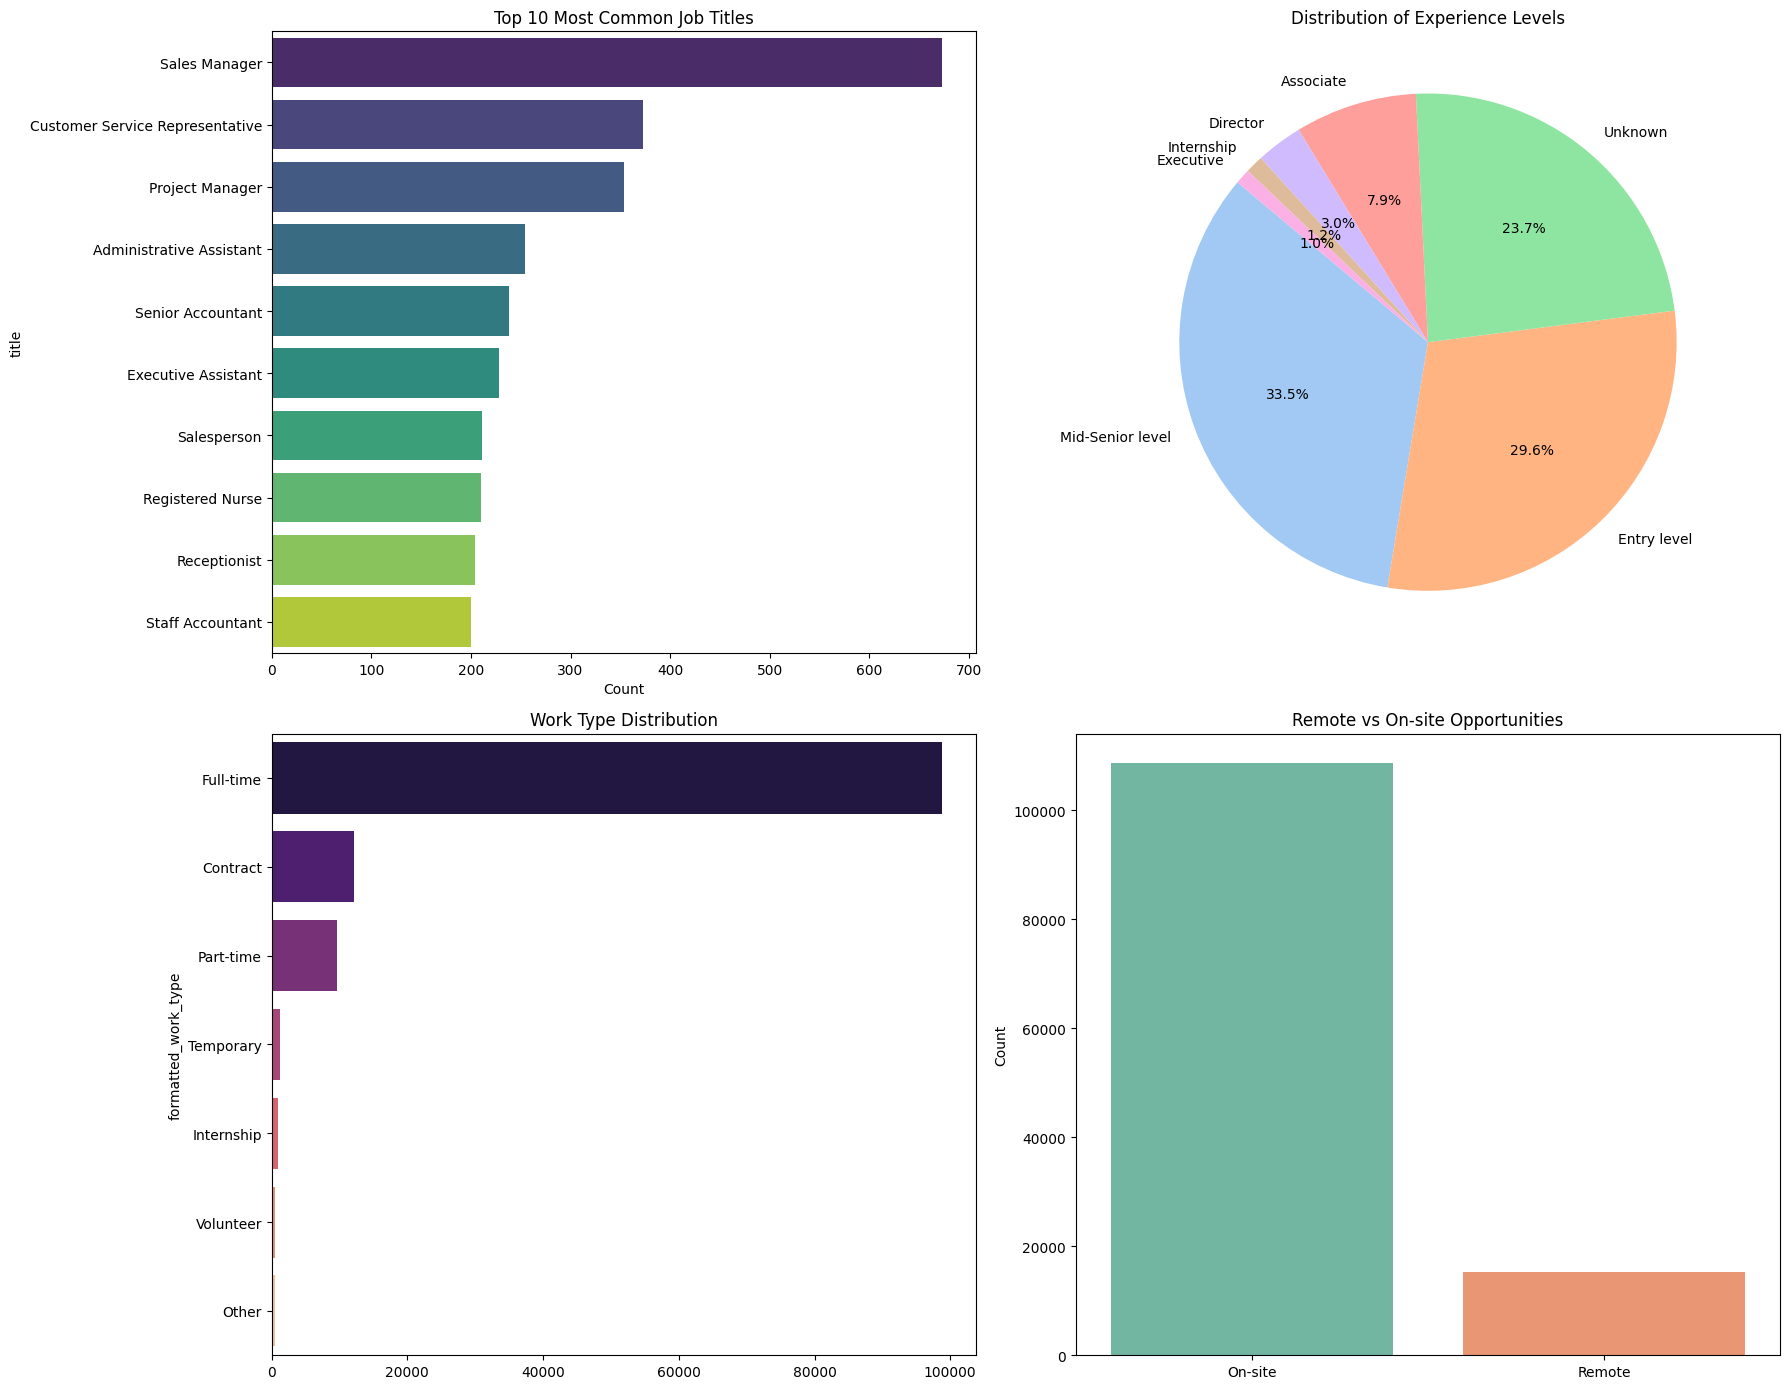

In [12]:
# --- BLOCK 3 (FULL & OPTIMIZED): JOB PROFILE & SKILL ANALYSIS ---

# ==========================================
# PHẦN A: PHÂN TÍCH CATEGORICAL (Biểu đồ cũ)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Top 10 Job Titles
top_titles = df_clean['title'].value_counts().head(10)
sns.barplot(x=top_titles.values, y=top_titles.index, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Top 10 Most Common Job Titles')
axes[0, 0].set_xlabel('Count')

# 2. Experience Level Distribution
exp_counts = df_clean['formatted_experience_level'].value_counts()
axes[0, 1].pie(exp_counts, labels=exp_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[0, 1].set_title('Distribution of Experience Levels')

# 3. Work Type (Full-time vs Contract vs Remote)
work_type_counts = df_clean['formatted_work_type'].value_counts()
sns.barplot(x=work_type_counts.values, y=work_type_counts.index, ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Work Type Distribution')

# 4. Remote vs On-site
# Kiểm tra nếu cột remote_allowed chỉ có 0 và 1
remote_labels = {0: 'On-site', 1: 'Remote'}
# Map giá trị 0/1 sang nhãn để hiển thị cho đẹp
df_clean['remote_label'] = df_clean['remote_allowed'].map(remote_labels)

sns.countplot(data=df_clean, x='remote_label', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Remote vs On-site Opportunities')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()




--- TEXT ANALYSIS (Optimized) ---


/var/folders/qw/15rb_9bn0_3fqr7dgvy560g40000gn/T/ipykernel_83618/3743593207.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=skills_df, x='Count', y='Skill', palette='magma')


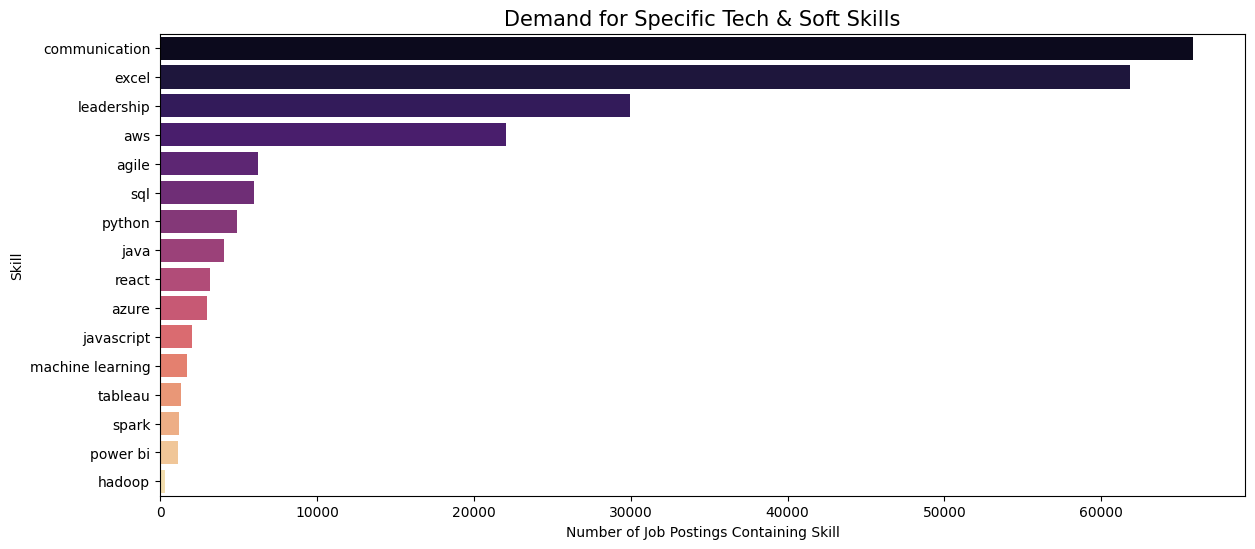

In [13]:
# ==========================================
# PHẦN B: PHÂN TÍCH TEXT & SKILLS 
# ==========================================
from collections import Counter

print("\n--- TEXT ANALYSIS (Optimized) ---")


# 4. Biểu đồ 2: Nhu cầu Kỹ năng cụ thể (Skill Demand)
# List các skill quan trọng cho ngành Data/IT (Bạn có thể thêm bớt tùy ý)
target_skills = [
    'python', 'sql', 'excel', 'java', 'aws', 'azure', 
    'communication', 'leadership', 'agile', 'tableau', 'power bi',
    'machine learning', 'spark', 'hadoop', 'react', 'javascript'
]

skill_counts = {}
for skill in target_skills:
    # Đếm số dòng chứa skill (dùng str.contains để bắt chính xác)
    count = df_clean['clean_description'].str.contains(skill, regex=False).sum()
    skill_counts[skill] = count

# Sắp xếp và vẽ
skills_df = pd.DataFrame(list(skill_counts.items()), columns=['Skill', 'Count']).sort_values(by='Count', ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(data=skills_df, x='Count', y='Skill', palette='magma')
plt.title('Demand for Specific Tech & Soft Skills', fontsize=15)
plt.xlabel('Number of Job Postings Containing Skill')
plt.show()

/var/folders/qw/15rb_9bn0_3fqr7dgvy560g40000gn/T/ipykernel_83618/853086527.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_salary, x='formatted_experience_level', y='standardized_annual_salary', order=existing_order, ax=axes[0, 1], palette='Set3')
/var/folders/qw/15rb_9bn0_3fqr7dgvy560g40000gn/T/ipykernel_83618/853086527.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_paid_jobs.values, y=top_paid_jobs.index, ax=axes[1, 0], palette='coolwarm')
/var/folders/qw/15rb_9bn0_3fqr7dgvy560g40000gn/T/ipykernel_83618/853086527.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set

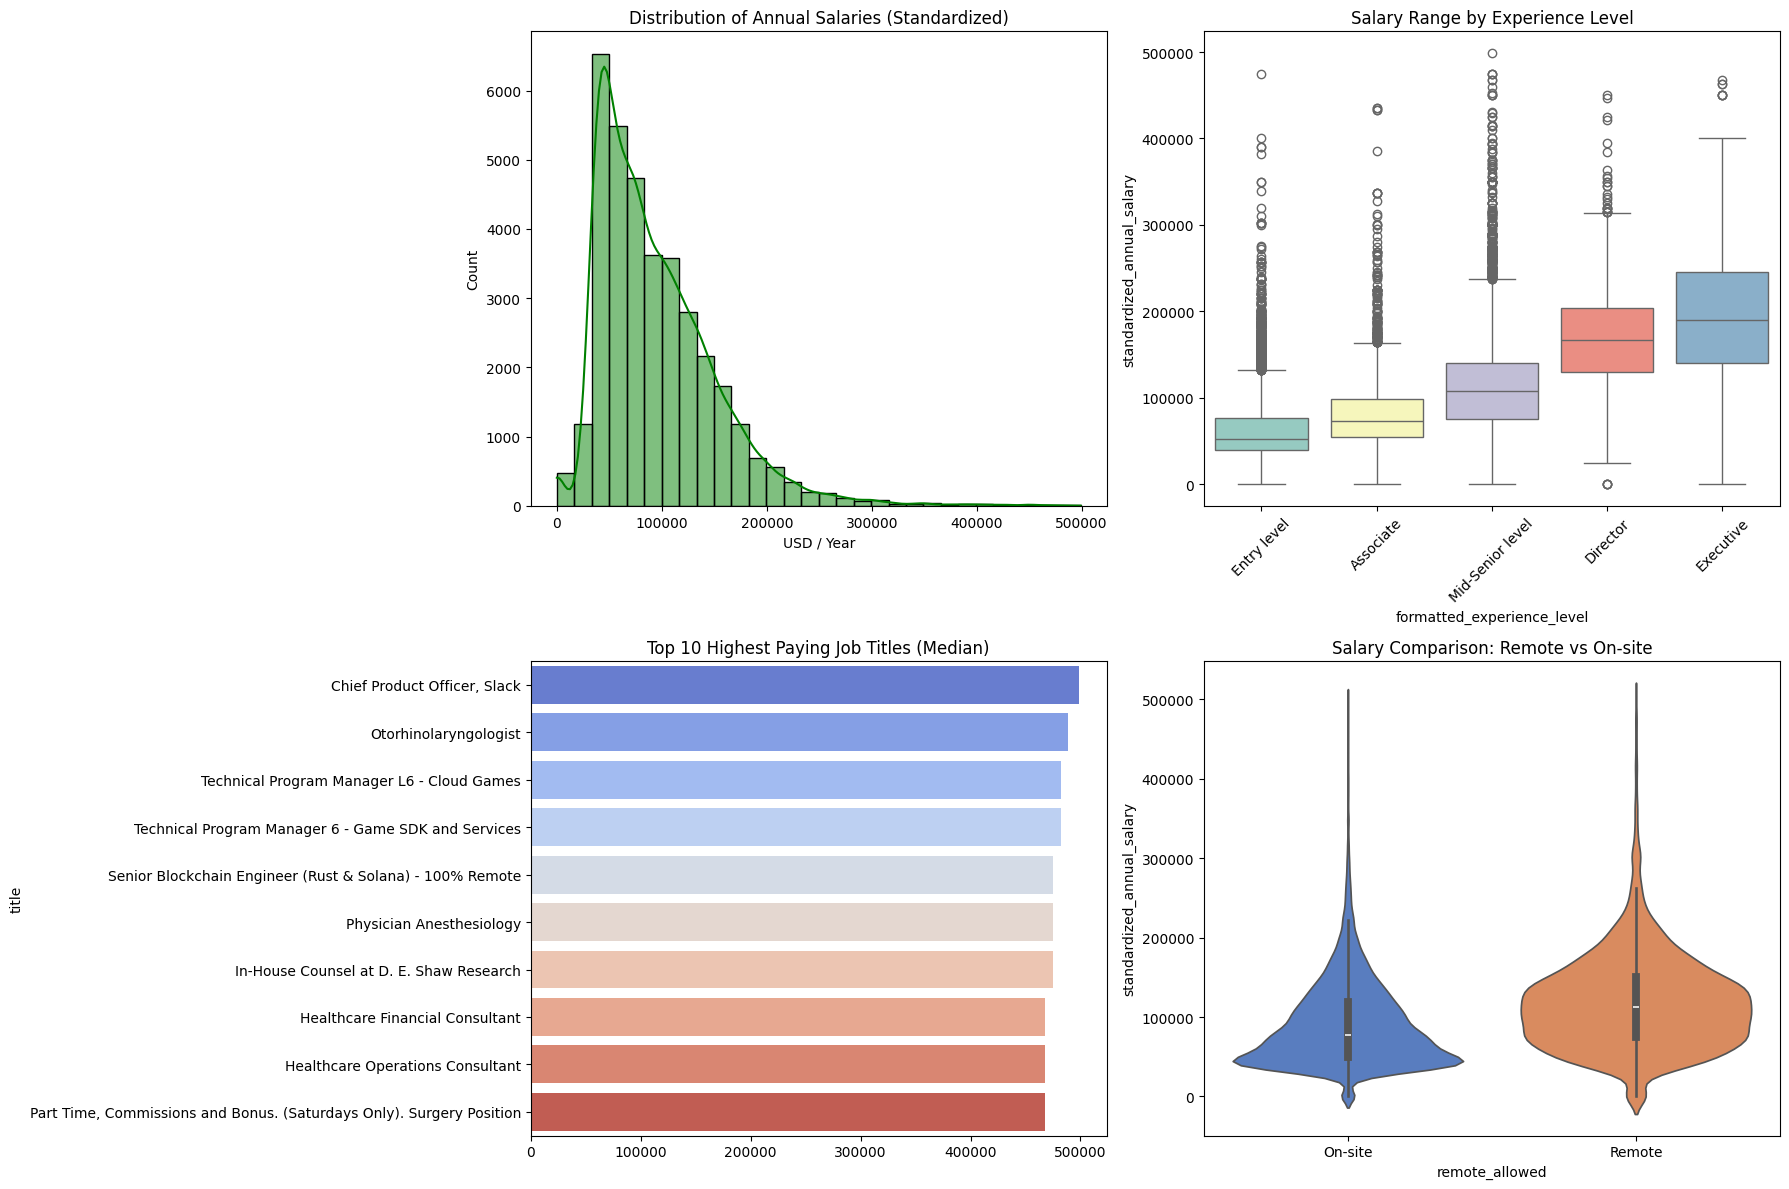

Salary Descriptive Statistics:
count     35976.000000
mean      94498.769510
std       56852.433861
min           0.000000
25%       51806.500000
50%       81120.000000
75%      124800.000000
max      499000.000000
Name: standardized_annual_salary, dtype: object


In [14]:
# --- BLOCK 4: PILLAR 2 - SALARY ANALYSIS ---

# Lọc dữ liệu có lương để vẽ biểu đồ
df_salary = df_clean.dropna(subset=['standardized_annual_salary'])
# Loại bỏ outlier cực đoan (nếu cần, ví dụ > 500k) để biểu đồ đẹp hơn
df_salary = df_salary[df_salary['standardized_annual_salary'] < 500000]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Phân phối lương (Histogram)
sns.histplot(df_salary['standardized_annual_salary'], bins=30, kde=True, ax=axes[0, 0], color='green')
axes[0, 0].set_title('Distribution of Annual Salaries (Standardized)')
axes[0, 0].set_xlabel('USD / Year')

# 2. Lương theo Kinh nghiệm (Boxplot)
order_exp = ['Entry level', 'Associate', 'Mid-Senior level', 'Director', 'Executive']
# Chỉ lấy các level có trong dữ liệu
existing_order = [x for x in order_exp if x in df_salary['formatted_experience_level'].unique()]
sns.boxplot(data=df_salary, x='formatted_experience_level', y='standardized_annual_salary', order=existing_order, ax=axes[0, 1], palette='Set3')
axes[0, 1].set_title('Salary Range by Experience Level')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Top 10 Job Titles có lương trung bình cao nhất
top_paid_jobs = df_salary.groupby('title')['standardized_annual_salary'].median().sort_values(ascending=False).head(10)
sns.barplot(x=top_paid_jobs.values, y=top_paid_jobs.index, ax=axes[1, 0], palette='coolwarm')
axes[1, 0].set_title('Top 10 Highest Paying Job Titles (Median)')

# 4. Lương: Remote vs On-site
sns.violinplot(data=df_salary, x='remote_allowed', y='standardized_annual_salary', ax=axes[1, 1], palette='muted')
axes[1, 1].set_xticklabels(['On-site', 'Remote'])
axes[1, 1].set_title('Salary Comparison: Remote vs On-site')

plt.tight_layout()
plt.show()

# In thống kê mô tả cơ bản
print("Salary Descriptive Statistics:")
print(df_salary['standardized_annual_salary'].describe().apply(lambda x: format(x, 'f')))

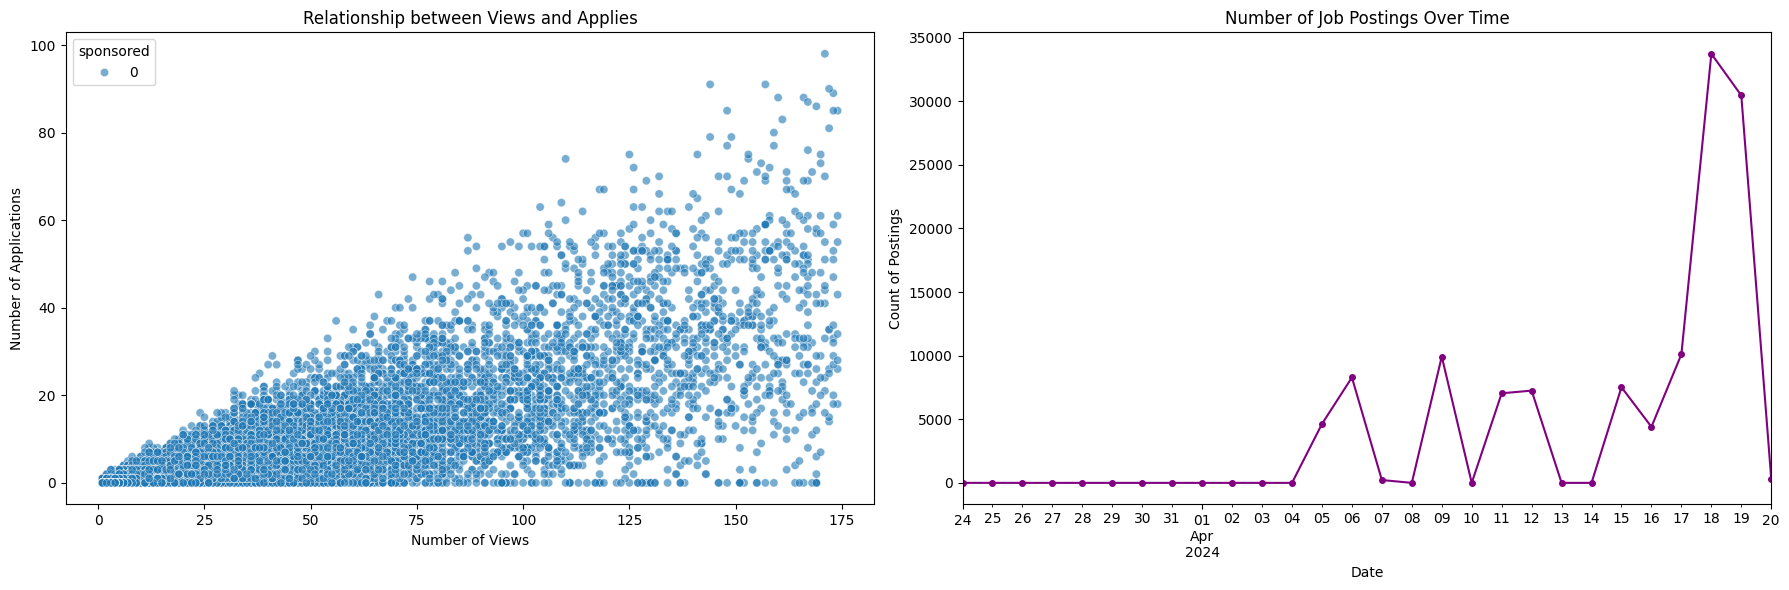

Average Conversion Rate (Applies/Views): 13.83%


In [15]:
# --- BLOCK 5: PILLAR 3 - ENGAGEMENT METRICS ---

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Scatter Plot: Views vs Applies (Tô màu theo Sponsored)
# Lọc bỏ các bài không có view để biểu đồ đỡ bị dồn cục
df_engage = df_clean[(df_clean['views'] > 0) & (df_clean['views'] < df_clean['views'].quantile(0.99))] 

sns.scatterplot(data=df_engage, x='views', y='applies', hue='sponsored', alpha=0.6, ax=axes[0])
axes[0].set_title('Relationship between Views and Applies')
axes[0].set_xlabel('Number of Views')
axes[0].set_ylabel('Number of Applications')

# 2. Posting Trend Over Time (Daily)
# Gom nhóm theo ngày
df_trend = df_clean.set_index('listed_time').resample('D').size()
df_trend.plot(ax=axes[1], color='purple', marker='o', markersize=4)
axes[1].set_title('Number of Job Postings Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Count of Postings')

plt.tight_layout()
plt.show()

# Tính tỷ lệ chuyển đổi trung bình
avg_conversion = (df_clean['applies'].sum() / df_clean['views'].sum()) * 100
print(f"Average Conversion Rate (Applies/Views): {avg_conversion:.2f}%")

✅ Đang phân tích Địa lý & Công ty (Đã xử lý lỗi hiển thị lương)...


/var/folders/qw/15rb_9bn0_3fqr7dgvy560g40000gn/T/ipykernel_83618/3481885310.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.values, y=state_counts.index, ax=axes[0], palette='Spectral')
/var/folders/qw/15rb_9bn0_3fqr7dgvy560g40000gn/T/ipykernel_83618/3481885310.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=company_counts.values, y=company_counts.index, ax=axes[1], palette='rocket')


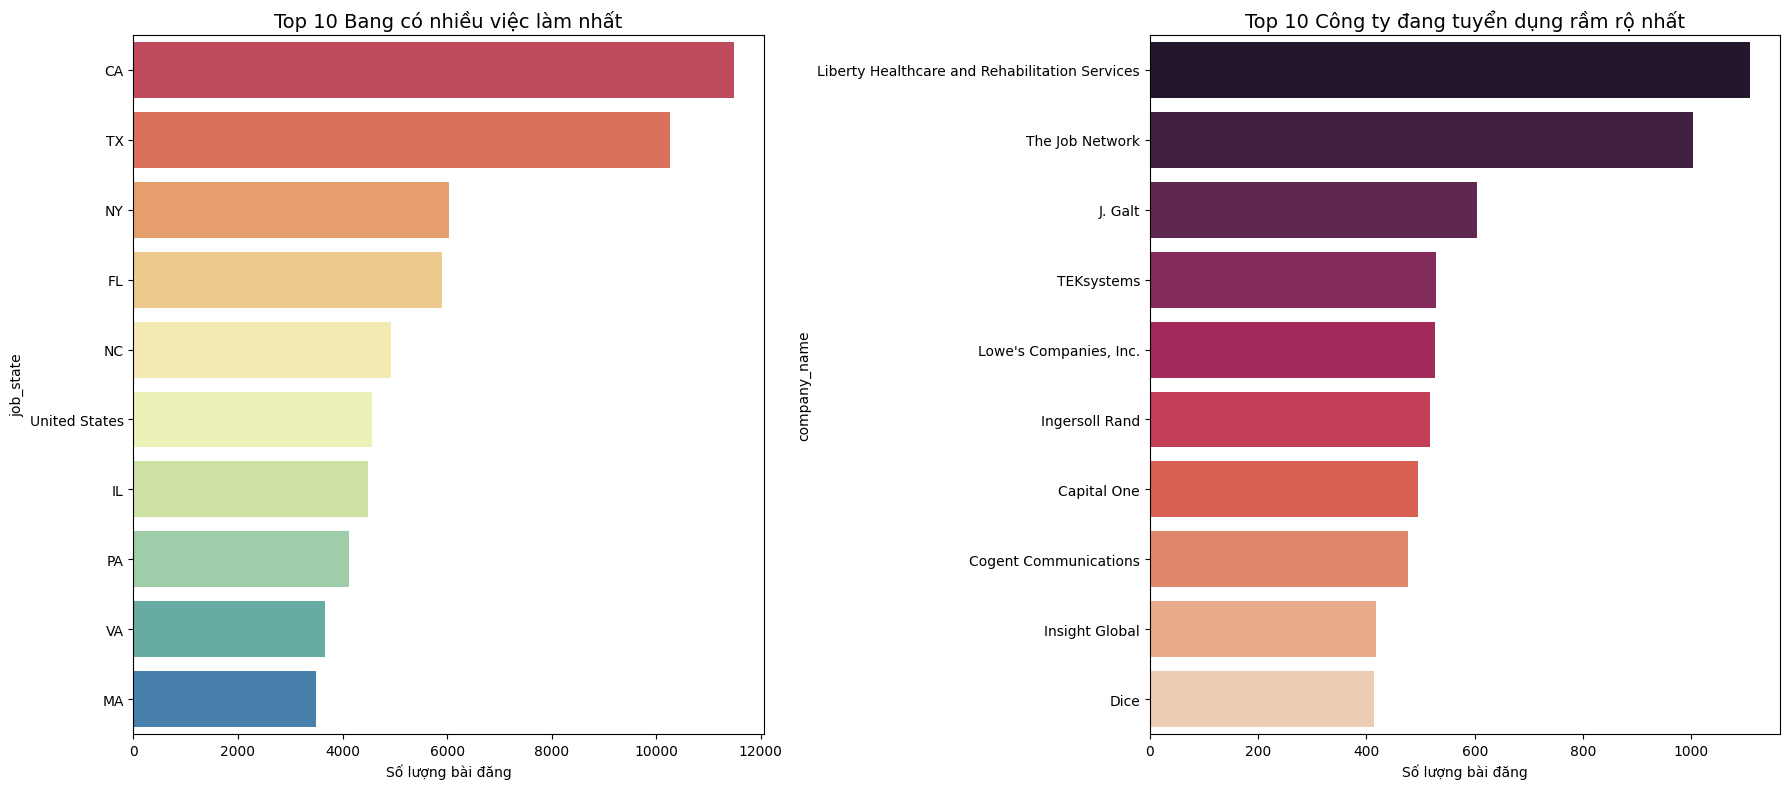


--- Insight mở rộng: Lương tại Top 5 Bang (Đã lọc nhiễu) ---


/var/folders/qw/15rb_9bn0_3fqr7dgvy560g40000gn/T/ipykernel_83618/3481885310.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_top_states, x='job_state', y='standardized_annual_salary', palette='Set2')


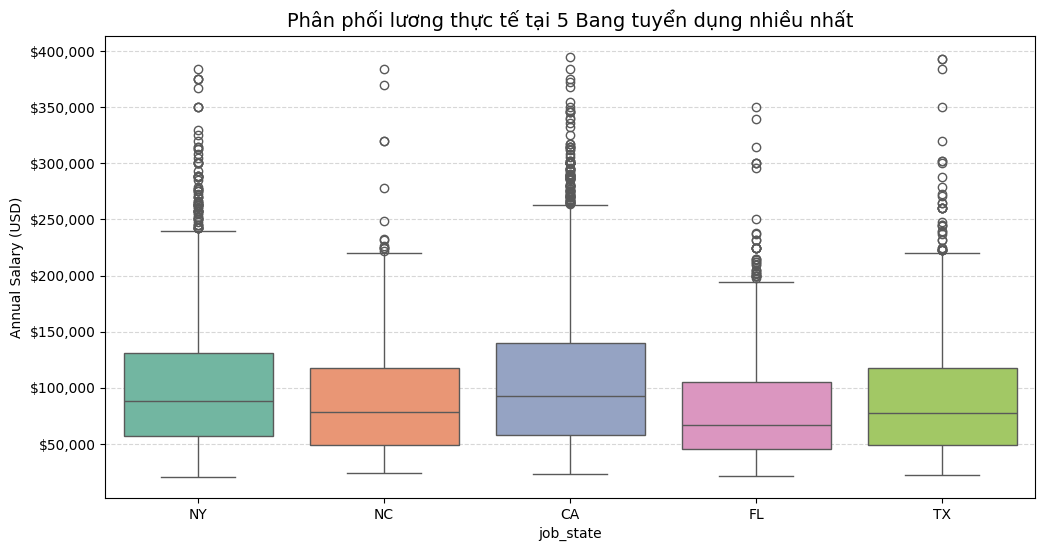

Bảng thống kê lương chi tiết theo Bang (Median):
           count     mean median_salary      max
job_state                                       
CA         5,692  105,408        92,500  395,220
FL         1,373   80,571        66,560  350,490
NC           827   89,252        78,000  383,900
NY         2,955  101,424        88,249  383,900
TX         1,934   89,578        77,500  393,500


In [17]:
# --- BLOCK 6 (FIXED): GEOGRAPHY & COMPANY ANALYSIS ---
from matplotlib.ticker import FuncFormatter

print("✅ Đang phân tích Địa lý & Công ty (Đã xử lý lỗi hiển thị lương)...")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# A. Top 10 Bang tuyển dụng nhiều nhất
# Lọc bỏ 'Unknown'
state_counts = df_clean[df_clean['job_state'] != 'Unknown']['job_state'].value_counts().head(10)

sns.barplot(x=state_counts.values, y=state_counts.index, ax=axes[0], palette='Spectral')
axes[0].set_title('Top 10 Bang có nhiều việc làm nhất', fontsize=14)
axes[0].set_xlabel('Số lượng bài đăng')

# B. Top 10 Công ty tuyển dụng nhiều nhất
company_counts = df_clean[df_clean['company_name'] != 'Unknown Company']['company_name'].value_counts().head(10)

sns.barplot(x=company_counts.values, y=company_counts.index, ax=axes[1], palette='rocket')
axes[1].set_title('Top 10 Công ty đang tuyển dụng rầm rộ nhất', fontsize=14)
axes[1].set_xlabel('Số lượng bài đăng')

plt.tight_layout()
plt.show()

# --- PHẦN SỬA LỖI: Insight Lương theo Bang ---
print("\n--- Insight mở rộng: Lương tại Top 5 Bang (Đã lọc nhiễu) ---")

# 1. Lấy danh sách 5 bang top đầu
top_5_states = state_counts.index[:5]
df_top_states = df_clean[df_clean['job_state'].isin(top_5_states)].copy()

# 2. QUAN TRỌNG: Lọc Outliers để biểu đồ không bị "kỳ"
# Chỉ lấy lương từ $20k đến $400k (Mức hợp lý cho thị trường Mỹ)
# Lương < 20k thường là lỗi hoặc part-time cực ngắn, > 400k thường là nhiễu
df_top_states = df_top_states[
    (df_top_states['standardized_annual_salary'] > 20000) & 
    (df_top_states['standardized_annual_salary'] < 400000)
]

# 3. Vẽ biểu đồ Boxplot
plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=df_top_states, x='job_state', y='standardized_annual_salary', palette='Set2')

# 4. Format trục Y thành tiền đô ($100,000) thay vì số khoa học (1e5)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.title('Phân phối lương thực tế tại 5 Bang tuyển dụng nhiều nhất', fontsize=14)
plt.ylabel('Annual Salary (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# 5. In ra bảng số liệu để check chéo (Sanity Check)
print("Bảng thống kê lương chi tiết theo Bang (Median):")
summary = df_top_states.groupby('job_state')['standardized_annual_salary'].describe()[['count', 'mean', '50%', 'max']]
summary = summary.rename(columns={'50%': 'median_salary'})
# Format số cho đẹp
print(summary.apply(lambda x: x.map('{:,.0f}'.format)))